# Correlate CDOM

In [24]:
# imports
import os
from importlib import reload
import numpy as np

from scipy.io import matlab

import seaborn as sns
from matplotlib import pyplot as plt
import corner

from matplotlib.ticker import MultipleLocator 
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import cartopy

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting

from bing import rt
from bing.priors import adg as bing_adg 

In [2]:
%matplotlib ipympl

In [3]:
tformM = ccrs.Mollweide()
tformP = ccrs.PlateCarree()  

# Load up Kehrli+2024

In [9]:
ag_dict, ad_dict = bing_adg.load_kehrli2024()
ag_dict.keys()

dict_keys(['wave', 'date', 'lat', 'lon', 'spec'])

## Fit $S$

In [11]:
reload(bing_adg)
Sg_tbl, Sd_tbl, Sdg_tbl = bing_adg.fit_exp_to_adg(ag_dict, ad_dict)

In [12]:
Sg_tbl.head()

,Ag,Sg
0,0.050983,0.021989
1,0.075974,0.016178
2,0.079362,0.016200
3,0.255676,0.017957
4,0.361729,0.017420


# Isolate 440

In [5]:
ag_i440 = np.argmin(np.abs(ag_dict['wave']-440.))
ad_i440 = np.argmin(np.abs(ad_dict['wave']-440.))

In [6]:
ag_440 = ag_dict['spec'][:,ag_i440]
ad_440 = ad_dict['spec'][:,ad_i440]

# $a_g(440)$ vs $S_g$

## Check $Ag$

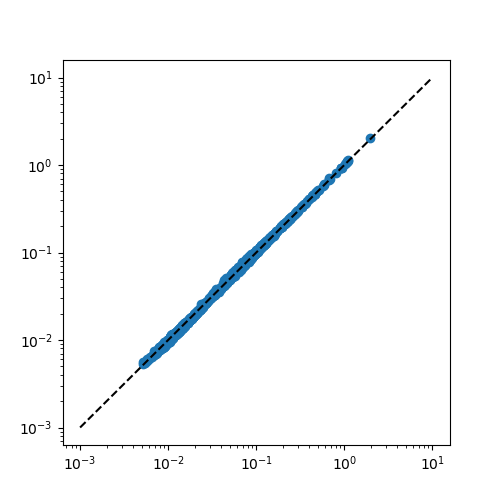

In [16]:
fig = plt.figure(figsize=(5,5))
ax = plt.gca()
ax.plot(ag_440, Sg_tbl.Ag, 'o')
#
ax.set_xscale('log')
ax.set_yscale('log')
#
ax.plot([1e-3,10], [1e-3,10], 'k--')
#
plt.show()

## Now $A_g$ vs. $S_g$

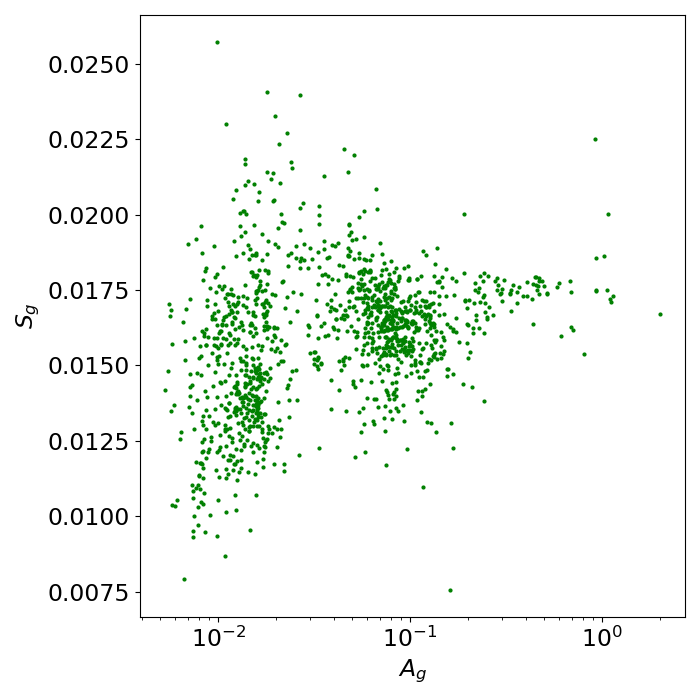

In [39]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
ax.plot(Sg_tbl.Ag, Sg_tbl.Sg, 'og', ms=2)
#
ax.set_xscale('log')
#ax.set_yscale('log')
#
ax.set_xlabel(r'$A_g$')
ax.set_ylabel(r'$S_g$')
#
#ax.plot([1e-3,10], [1e-3,10], 'k--')
plotting.set_fontsize(ax, 17)
#
plt.tight_layout()
plt.show()

# Corner me

In [29]:
ag_dict['lat'].shape

(1293, 1)

In [40]:
coeff = []
coeff.append(ag_dict['lat'].flatten())
coeff.append(ag_dict['lon'].flatten())
coeff.append(np.log10(ag_tbl.Ag))
coeff.append(ag_tbl.Sg)
coeff = np.array(coeff).T
coeff.shape
# Labels
clbls = ['lat', 'lon', 'log10 Ag', 'Sg']

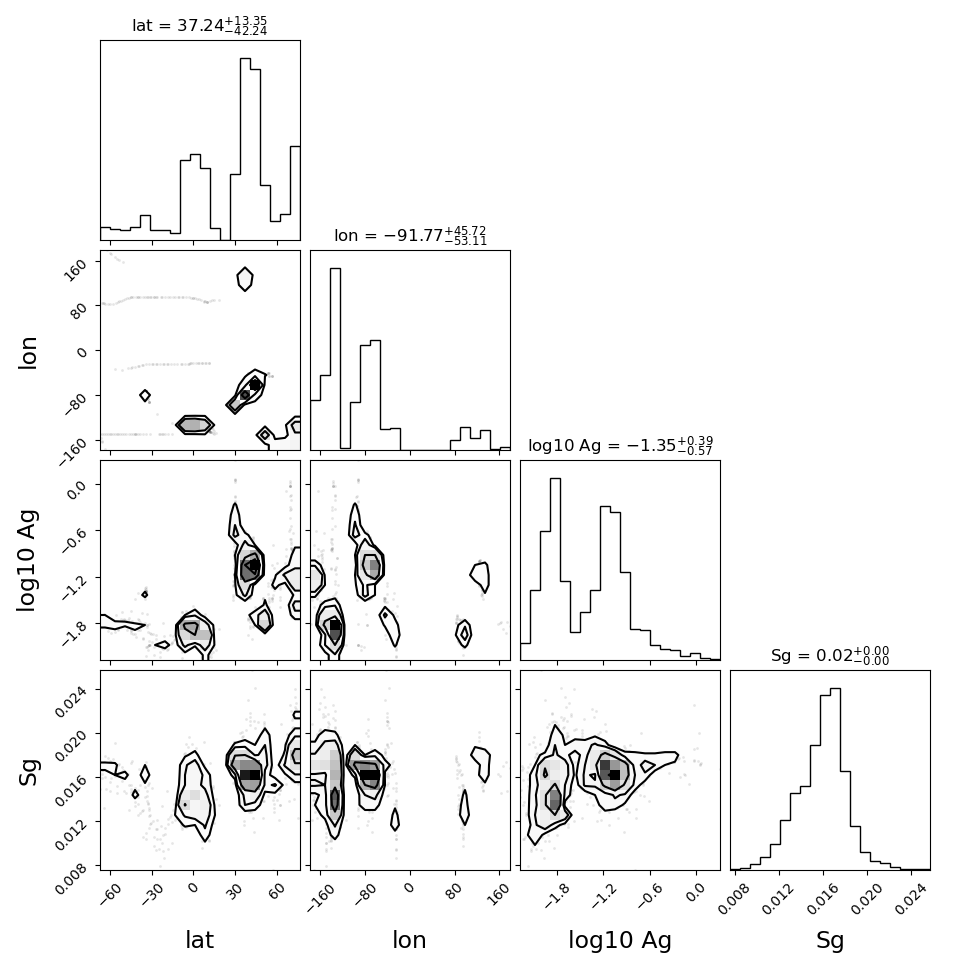

In [41]:
fig = corner.corner(
        coeff, labels=clbls,
        label_kwargs={'fontsize':17},
        color='k',
        #axes_scale='log',
        #truths=truths,
        show_titles=True,
        title_kwargs={"fontsize": 12},
        )

#plotting.set_fontsize(ax, 17)

plt.show()